# 14 — Sky CNN: MobileNetV3Small (โมดูลแยก ไม่ได้ใช้คำนวณค่า UV)

ผลมาจาก `python -m src.sky_cnn --train` แล้วตามด้วย `--test` (test split อ่าน**ครั้งเดียว** หลังประกาศเกณฑ์ใน commit `12c1828`) notebook นี้อ่านผลที่บันทึกไว้

- **Input:** ภาพ [0, 1] ภายในโมเดลมี `Rescaling(255)` → MobileNetV3Small (`include_preprocessing=True`)
- **CCSN:** ตัดกลุ่ม `label_conflict` ออก รายงานทั้ง 11 ชนิดและ 4 กลุ่ม UV (สิ่งที่แอปจะแสดง)
- **SWIMCAT-ext:** รายงานทั้งรายภาพและรายกลุ่มภาพไม่ซ้ำ
- **สัดส่วนเมฆ:** red/blue ratio ตรวจได้แค่แบบ proxy เพราะยังไม่มี SWIMSEG

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

from src import sky_cnn as sc
from src import sky_data as sd

m = json.loads(sc.METRICS_PATH.read_text(encoding="utf-8"))
t = json.loads(sc.TEST_PATH.read_text(encoding="utf-8"))
print("n:", m["n"], "| exported seed:", m["exported_seed"])
display(pd.DataFrame(m["val_runs"]).round(3))
print("val colour baseline:", {k: round(v, 3) for k, v in m["val_color_baseline"].items()})

n: {'train_ccsn': 1601, 'train_swim': 1472, 'val_ccsn': 353, 'val_swim': 317} | exported seed: 43


,seed,ccsn_acc,ccsn_f1,ccsn_group_acc,swim_acc,swim_group_acc,val_loss
0,42,0.521,0.479,0.717,0.991,0.989,0.763
1,43,0.518,0.480,0.708,0.984,0.979,0.751
2,44,0.516,0.456,0.703,0.987,0.989,0.759


val colour baseline: {'ccsn_acc': 0.314, 'swim_group_acc': 0.799}


## 1. Learning curves (val loss; ขั้น 1 = freeze backbone, ขั้น 2 = fine-tune)

seed 42: no epoch history (model reloaded), best val loss 0.7630
seed 43: no epoch history (model reloaded), best val loss 0.7505


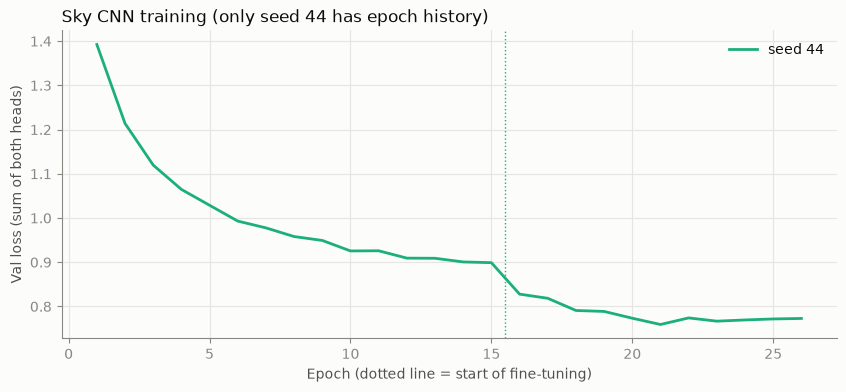

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"42": C_OM, "43": C_NASA, "44": C_THIRD}
for s, h in m["histories"].items():
    if h.get("stage1") is None:  # seeds 42/43: epoch history lost in the sleep crash
        print(f"seed {s}: no epoch history (model reloaded), best val loss {h['best_val_loss']:.4f}")
        continue
    v1, v2 = h["stage1"]["val_loss"], h["stage2"]["val_loss"]
    ep = np.arange(1, len(v1) + len(v2) + 1)
    ax.plot(ep, v1 + v2, color=colors[s], label=f"seed {s}")
    ax.axvline(len(v1) + 0.5, color=colors[s], ls=":", lw=1)
ax.set_xlabel("Epoch (dotted line = start of fine-tuning)")
ax.set_ylabel("Val loss (sum of both heads)")
ax.set_title("Sky CNN training (only seed 44 has epoch history)", loc="left")
ax.legend(loc="upper right")
save(fig, "sky_cnn_learning_curves.png")

## 2. ผลบน test (ค่าเฉลี่ย ± SD ของ 3 seeds) เทียบกับเกณฑ์

In [4]:
display(pd.DataFrame(t["criteria"]).round(3))
rows = []
for name, key in [("CCSN (conflicts removed)", "ccsn"), ("CCSN incl. conflicts", "ccsn_with_conflicts")]:
    for k in ("accuracy", "macro_f1", "group_accuracy"):
        rows.append({"set": name, "metric": k, "mean": t[key]["mean"][k], "sd": t[key]["sd"][k]})
for k in ("accuracy", "group_accuracy"):
    rows.append({"set": "SWIMCAT-ext", "metric": k, "mean": t["swim"]["mean"][k], "sd": t["swim"]["sd"][k]})
display(pd.DataFrame(rows).round(3))
print("n:", t["n"])
print("colour baseline (test):", {k: round(v, 3) for k, v in t["color_baseline"].items()})
print("UV-group recall (mean):", {k: round(v, 3) for k, v in t["ccsn"]["mean"]["group_recall"].items()})

,id,criterion,value,passed
0,K1,CCSN 11-class accuracy (conflicts removed) >= ...,0.486,False
1,K2,CCSN 11-class macro-F1 >= 0.55,0.452,False
2,K3,CCSN 4 UV-group accuracy >= 0.75,0.685,False
3,K4,CCSN UV-group recall of high_thin >= 0.70,0.707,True
4,K5,CCSN 11-class accuracy >= colour baseline + 0.10,0.243,True
5,S1,SWIMCAT-ext per-image accuracy >= 0.85,0.975,True
6,S2,SWIMCAT-ext per-group accuracy >= 0.80,0.967,True
7,S3,SWIMCAT-ext per-group accuracy >= colour basel...,0.149,True
8,R1,red/blue proxy: median cloud fraction of clear...,0.001,True
9,R2,"red/blue proxy: median of thick_white, thick_d...",0.656,True


,set,metric,mean,sd
0,CCSN (conflicts removed),accuracy,0.486,0.010
1,CCSN (conflicts removed),macro_f1,0.452,0.023
2,CCSN (conflicts removed),group_accuracy,0.685,0.009
3,CCSN incl. conflicts,accuracy,0.462,0.011
4,CCSN incl. conflicts,macro_f1,0.438,0.024
5,CCSN incl. conflicts,group_accuracy,0.692,0.009
6,SWIMCAT-ext,accuracy,0.975,0.007
7,SWIMCAT-ext,group_accuracy,0.967,0.010


n: {'ccsn': 326, 'ccsn_with_conflicts': 375, 'swim_images': 311, 'swim_groups': 181}
colour baseline (test): {'ccsn_acc': 0.242, 'swim_acc': 0.839, 'swim_group_acc': 0.818}
UV-group recall (mean): {'high_thin': 0.707, 'mid': 0.366, 'low_thick': 0.864, 'cumulus': 0.413}


## 3. Confusion matrix (รวม 3 seeds, แถว = ค่าจริง)

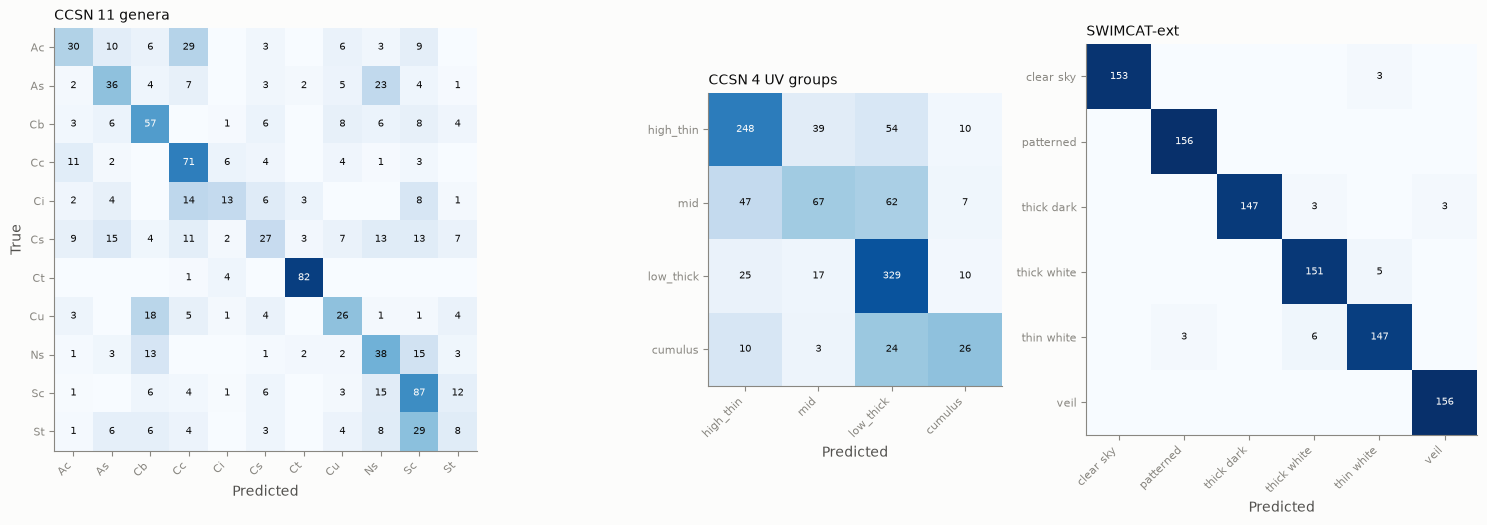

In [5]:
def plot_cm(ax, cm, labels, title):
    cm = np.asarray(cm, float)
    norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j]:
                ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=7,
                        color="#fcfcfb" if norm[i, j] > 0.5 else INK)
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_title(title, loc="left", fontsize=10); ax.grid(False)

summed = lambda key, f: np.sum([r[f] for r in t[key]], axis=0)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"width_ratios": [11, 4.5, 6]})
plot_cm(axes[0], summed("ccsn_runs", "confusion"), sc.CCSN_CLASSES, "CCSN 11 genera")
plot_cm(axes[1], summed("ccsn_runs", "group_confusion"), list(sc.UV_GROUPS), "CCSN 4 UV groups")
plot_cm(axes[2], summed("swim_runs", "confusion"), [c.replace("_clouds", "").replace("_", " ") for c in sc.SWIM_CLASSES], "SWIMCAT-ext")
axes[0].set_ylabel("True")
fig.tight_layout()
save(fig, "sky_cnn_confusion.png")

## 4. สัดส่วนเมฆจาก red/blue ratio (proxy บน SWIMCAT-ext test)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
clear_sky,52.0,0.114,0.208,0.000,0.000,0.001,0.156,0.773
patterned_clouds,52.0,0.688,0.205,0.163,0.534,0.693,0.825,1.000
thick_dark_clouds,51.0,0.773,0.329,0.026,0.613,0.969,1.000,1.000
thick_white_clouds,52.0,0.672,0.223,0.307,0.476,0.656,0.874,1.000
thin_white_clouds,52.0,0.409,0.203,0.073,0.206,0.415,0.571,0.805
veil_clouds,52.0,0.943,0.222,0.055,1.000,1.000,1.000,1.000


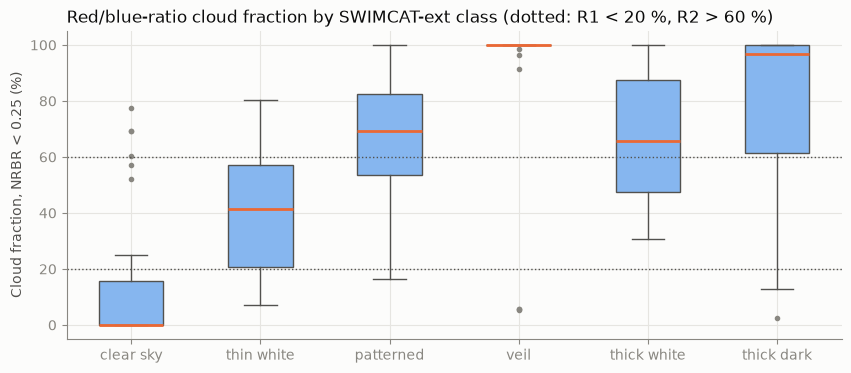

In [6]:
test_s = sd.load_split("swimcat_ext", "test", confirm_test=True)
frac = [sc.rb_cloud_fraction(sd.load_image(sd.resolve(p))) for p in test_s["path"]]
test_s = test_s.assign(rb=frac)
order = ["clear_sky", "thin_white_clouds", "patterned_clouds", "veil_clouds", "thick_white_clouds", "thick_dark_clouds"]
fig, ax = plt.subplots(figsize=(10, 4))
data = [test_s.loc[test_s["label"] == c, "rb"] * 100 for c in order]
ax.boxplot(data, widths=0.5, patch_artist=True, boxprops={"facecolor": "#86b6ef", "edgecolor": INK2},
           medianprops={"color": C_NASA, "linewidth": 2}, whiskerprops={"color": INK2}, capprops={"color": INK2},
           flierprops={"markersize": 3, "markerfacecolor": MUTED, "markeredgecolor": MUTED})
ax.set_xticks(range(1, 7), [c.replace("_clouds", "").replace("_", " ") for c in order])
ax.axhline(20, color=INK2, ls=":", lw=1); ax.axhline(60, color=INK2, ls=":", lw=1)
ax.set_ylabel("Cloud fraction, NRBR < 0.25 (%)")
ax.set_title("Red/blue-ratio cloud fraction by SWIMCAT-ext class (dotted: R1 < 20 %, R2 > 60 %)", loc="left")
save(fig, "sky_rb_cloud_fraction.png")
test_s.groupby("label")["rb"].describe().round(3)

## สรุปผล test (อ่านครั้งเดียว, ค่าเฉลี่ย 3 seeds ± SD)

**ผ่าน 7 / 10 เกณฑ์ที่ประกาศไว้ ไม่ผ่าน K1, K2, K3** และหลังเห็นผลไม่ได้แก้โมเดล ข้อมูล หรือ config

| # | ผล test | เกณฑ์ | ผ่าน |
|---|---|---|---|
| K1 | CCSN 11 คลาส accuracy **0.486 ± 0.010** (n 326) | ≥ 0.60 | ❌ |
| K2 | CCSN macro-F1 **0.452 ± 0.023** | ≥ 0.55 | ❌ |
| K3 | CCSN 4 กลุ่ม UV accuracy **0.685 ± 0.009** | ≥ 0.75 | ❌ |
| K4 | recall "เมฆบางระดับสูง" **0.707** | ≥ 0.70 | ✅ (เฉียดฉิว) |
| K5 | CCSN − baseline สี: 0.486 − 0.242 = **+0.243** | ≥ +0.10 | ✅ |
| S1 | SWIMCAT-ext รายภาพ **0.975 ± 0.007** (311 ภาพ) | ≥ 0.85 | ✅ |
| S2 | SWIMCAT-ext รายกลุ่ม **0.967 ± 0.010** (181 กลุ่มภาพไม่ซ้ำ) | ≥ 0.80 | ✅ |
| S3 | SWIMCAT-ext รายกลุ่ม − baseline สี: 0.967 − 0.818 = **+0.149** | ≥ +0.05 | ✅ |
| R1 | red/blue: median สัดส่วนเมฆ clear_sky **0.001** | < 0.20 | ✅ |
| R2 | red/blue: median thick_white **0.656**, thick_dark 0.969, veil 1.000 | > 0.60 ทุกคลาส | ✅ |

- **CCSN แบบรวมกลุ่ม label_conflict** (375 ภาพ, ไม่มีเกณฑ์): accuracy 0.462, macro-F1 0.438, กลุ่ม UV 0.692
- **recall รายกลุ่ม UV:** เมฆบางระดับสูง 0.71, เมฆระดับกลาง **0.37**, เมฆหนาระดับต่ำ 0.86, เมฆก้อน **0.41** กลุ่มที่แย่คือเมฆระดับกลาง (Ac/As) และเมฆก้อน (Cu) ส่วน val ใกล้กับ test (CCSN 0.52, กลุ่ม UV 0.71) จึงไม่ได้เป็นผลจาก overfit กับ val
- **ความหมาย:**
  - งานจำแนก**สภาพท้องฟ้า** (SWIMCAT-ext) ใช้ได้ดี
  - งานจำแนก**ชนิดเมฆ** (CCSN) ยากกว่ามากและ**ไม่ถึงเกณฑ์** ทั้ง 11 ชนิดและ 4 กลุ่ม UV
  - ในแอปควรแสดงผล CCSN พร้อมความน่าจะเป็นและคำเตือนว่าไม่แน่นอน หรือแสดงเฉพาะผลจาก SWIMCAT-ext ต้องตัดสินใจในวัน 16–20
- **ข้อจำกัด:**
  - SWIMCAT-ext มีภาพซ้ำเยอะ (311 ภาพเหลือ 181 กลุ่ม) และคลาสแยกกันด้วยสีได้ค่อนข้างง่าย (baseline สีได้ 0.82)
  - red/blue ratio ตรวจได้แค่แบบ proxy เพราะยังไม่มี SWIMSEG
  - ช่องว่างระหว่างภาพ dataset กับภาพจากมือถือที่ปทุมธานียังไม่ได้วัด
  - history ราย epoch ของ seed 42/43 หายไปตอนเครื่อง sleep (ใช้โมเดลที่บันทึกไว้ได้ตามปกติ)